# Bank Churn — Model 2/3: XGBoost

**Series:** `02_logistic_regression` → `03_xgboost` (this notebook) → `04_lightgbm`.

Protocol is identical to the logistic notebook so every number is directly comparable:

1. Same leakage-free preprocessing pipeline (+ SMOTE inside the CV loop)
2. Imbalance-strategy comparison: no correction vs `scale_pos_weight` vs SMOTE
3. **Broad RandomizedSearchCV → refined GridSearchCV** around the found optimum
4. Full held-out evaluation: ROC curve, PR curve, confusion matrices, classification
   report, threshold analysis
5. Interpretability: SHAP (TreeExplainer) — global summary + dependence structure

Reference to beat (from `02_logistic_regression`): **test ROC-AUC 0.8389, PR-AUC 0.6625.**
EDA says the gap should come from two places the linear model cannot represent: the
non-linear age effect and the U-shaped product-count effect.

## 1. Setup & data

In [1]:
import os
import shutil
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "data/Churn_Modelling.csv"
KAGGLE_DATASET = "shrutimechlearn/churn-modelling"
MIRROR_URL = (
    "https://raw.githubusercontent.com/sharmaroshan/"
    "Churn-Modelling-Dataset/master/Churn_Modelling.csv"
)


def fetch_data(path: str = DATA_PATH) -> str:
    """Download the dataset from Kaggle, falling back to a GitHub mirror."""
    if os.path.exists(path):
        print(f"Found cached file: {path}")
        return path
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        import kagglehub  # pip install kagglehub

        download_dir = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_files = [f for f in os.listdir(download_dir) if f.endswith(".csv")]
        shutil.copy(os.path.join(download_dir, csv_files[0]), path)
        print(f"Downloaded from Kaggle: {KAGGLE_DATASET}")
    except Exception as exc:
        print(f"Kaggle download failed ({exc!r}), using GitHub mirror.")
        urllib.request.urlretrieve(MIRROR_URL, path)
        print(f"Downloaded from mirror: {MIRROR_URL}")
    return path


df = pd.read_csv(fetch_data())
assert df.shape == (10_000, 14) and df.isnull().sum().sum() == 0
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
print(f"Rows: {len(df)}, churn rate: {df['Exited'].mean():.2%}")

Found cached file: data/Churn_Modelling.csv
Rows: 10000, churn rate: 20.37%


## 2. Preprocessing pipeline

Deliberately **identical** to the logistic notebook — same domain features, same
encoder/scaler, same split. Trees don't need standardized inputs, but keeping the
transformation fixed isolates the *model* as the only changing variable in the series.
(`products_cat` stays categorical too; XGBoost would also capture the U-shape from the
raw integer, and the one-hot form costs it nothing.)

In [2]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier


class DomainFeatures(BaseEstimator, TransformerMixin):
    """Adds EDA-motivated features; keeps the DataFrame interface."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["zero_balance"] = (X["Balance"] == 0).astype(int)
        X["balance_salary_ratio"] = X["Balance"] / (X["EstimatedSalary"] + 1.0)
        X["german_balance"] = (X["Geography"] == "Germany") * X["Balance"] / 1e5
        X["products_cat"] = X["NumOfProducts"].astype(str)
        X["inactive_senior"] = ((X["IsActiveMember"] == 0) & (X["Age"] >= 45)).astype(int)
        return X


CATEGORICAL = ["Geography", "Gender", "products_cat"]
NUMERIC = [
    "CreditScore", "Age", "Tenure", "Balance", "HasCrCard",
    "IsActiveMember", "EstimatedSalary", "zero_balance", "balance_salary_ratio",
    "german_balance", "inactive_senior",
]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), CATEGORICAL),
    ("num", StandardScaler(), NUMERIC),
])

X = df.drop(columns=["Exited"])
y = df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)
print(f"Train: {X_train.shape[0]} (churn {y_train.mean():.2%}) | "
      f"Test: {X_test.shape[0]} (churn {y_test.mean():.2%})")

Train: 8000 (churn 20.38%) | Test: 2000 (churn 20.35%)


## 3. Imbalance strategy comparison

The tree-native alternative to `class_weight` is `scale_pos_weight` — gradient
contributions of the positive class are multiplied by neg/pos ≈ 3.9. Same question as
before: does any correction move the ranking metrics, or only the threshold behavior?

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision",
           "f1": "f1", "recall": "recall", "brier": "neg_brier_score"}

spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {spw:.2f}")

base_xgb = dict(
    n_estimators=400, learning_rate=0.05, max_depth=4, min_child_weight=5,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    tree_method="hist", eval_metric="logloss",
    random_state=RANDOM_STATE, n_jobs=-1,
)

strategies = {
    "No correction": ImbPipeline([
        ("domain", DomainFeatures()), ("prep", preprocessor),
        ("clf", XGBClassifier(**base_xgb)),
    ]),
    "scale_pos_weight": ImbPipeline([
        ("domain", DomainFeatures()), ("prep", preprocessor),
        ("clf", XGBClassifier(scale_pos_weight=spw, **base_xgb)),
    ]),
    "SMOTE": ImbPipeline([
        ("domain", DomainFeatures()), ("prep", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", XGBClassifier(**base_xgb)),
    ]),
}

rows = []
for name, pipe in strategies.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "strategy": name,
        **{m: f"{res[f'test_{m}'].mean():.4f}" for m in ["roc_auc", "pr_auc", "f1", "recall"]},
        "brier": f"{-res['test_brier'].mean():.4f}",
    })
print(pd.DataFrame(rows).set_index("strategy").to_string())

scale_pos_weight = 3.91
                 roc_auc  pr_auc      f1  recall   brier
strategy                                                
No correction     0.8631  0.6941  0.5893  0.4933  0.1030
scale_pos_weight  0.8615  0.6947  0.6088  0.7153  0.1321
SMOTE             0.8616  0.6935  0.6154  0.5785  0.1072


We keep the **SMOTE pipeline** as the tuning target for series consistency and tune its
sampling parameters jointly with the tree hyperparameters — the search itself will tell
us whether aggressive or minimal oversampling wins.

## 4. Hyperparameter search — stage 1: broad RandomizedSearchCV

Joint space over capacity, sampling and regularization:

| Parameter | Distribution |
|---|---|
| `clf__n_estimators` | randint 200–800 |
| `clf__learning_rate` | log-uniform 0.01–0.3 |
| `clf__max_depth` | randint 3–8 |
| `clf__min_child_weight` | randint 1–12 |
| `clf__subsample`, `clf__colsample_bytree` | uniform 0.6–1.0 |
| `clf__gamma` | log-uniform 1e-3–5 |
| `clf__reg_lambda` | log-uniform 0.1–30 |
| `smote__k_neighbors` | {3, 5, 7, 9, 11} |
| `smote__sampling_strategy` | {0.4, 0.6, 0.8, 1.0} |

40 candidates × 5 folds = 200 fits. Objective: ROC-AUC.

In [4]:
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

smote_pipe = strategies["SMOTE"]

param_dist = {
    "clf__n_estimators": randint(200, 800),
    "clf__learning_rate": loguniform(0.01, 0.3),
    "clf__max_depth": randint(3, 9),
    "clf__min_child_weight": randint(1, 13),
    "clf__subsample": uniform(0.6, 0.4),
    "clf__colsample_bytree": uniform(0.6, 0.4),
    "clf__gamma": loguniform(1e-3, 5),
    "clf__reg_lambda": loguniform(0.1, 30),
    "smote__k_neighbors": [3, 5, 7, 9, 11],
    "smote__sampling_strategy": [0.4, 0.6, 0.8, 1.0],
}

random_search = RandomizedSearchCV(
    smote_pipe, param_dist, n_iter=40, cv=cv, scoring="roc_auc",
    random_state=RANDOM_STATE, n_jobs=1, refit=False, verbose=0,
)
random_search.fit(X_train, y_train)

rs_best = random_search.best_params_
print(f"Best CV ROC-AUC (random stage): {random_search.best_score_:.4f}")
print("Best params:")
for k, v in sorted(rs_best.items()):
    print(f"  {k}: {v}")

rs_df = pd.DataFrame(random_search.cv_results_)
top5 = rs_df.nlargest(5, "mean_test_score")[
    ["mean_test_score", "std_test_score", "param_clf__max_depth",
     "param_clf__learning_rate", "param_clf__n_estimators",
     "param_smote__sampling_strategy"]
]
print("\nTop-5 configurations:")
print(top5.to_string(index=False))

Best CV ROC-AUC (random stage): 0.8646
Best params:
  clf__colsample_bytree: 0.9849789179768444
  clf__gamma: 0.008537587346124054
  clf__learning_rate: 0.05426206745606973
  clf__max_depth: 3
  clf__min_child_weight: 5
  clf__n_estimators: 280
  clf__reg_lambda: 0.4579825393889128
  clf__subsample: 0.9906459823330611
  smote__k_neighbors: 9
  smote__sampling_strategy: 0.6

Top-5 configurations:
 mean_test_score  std_test_score  param_clf__max_depth  param_clf__learning_rate  param_clf__n_estimators  param_smote__sampling_strategy
        0.864609        0.010763                     3                  0.054262                      280                             0.6
        0.864240        0.010190                     6                  0.024113                      589                             0.8
        0.862999        0.011003                     4                  0.038660                      672                             0.8
        0.862692        0.011498                 

## 5. Hyperparameter search — stage 2: GridSearchCV around the optimum

The refinement grid is built **programmatically around the stage-1 winner** on the three
parameters that matter most for boosted trees (depth, learning rate, min_child_weight);
everything else is frozen at the winner. 3 × 3 × 3 = 27 combinations × 5 folds.

In [5]:
d = rs_best["clf__max_depth"]
lr = rs_best["clf__learning_rate"]
mcw = rs_best["clf__min_child_weight"]

frozen = {k: v for k, v in rs_best.items()
          if k not in {"clf__max_depth", "clf__learning_rate", "clf__min_child_weight"}}
smote_pipe.set_params(**frozen)

param_grid = {
    "clf__max_depth": sorted({max(2, d - 1), d, d + 1}),
    "clf__learning_rate": sorted({round(lr * f, 4) for f in (0.5, 1.0, 2.0)}),
    "clf__min_child_weight": sorted({max(1, mcw - 3), mcw, mcw + 3}),
}
print("Refinement grid:", param_grid)

grid_search = GridSearchCV(
    smote_pipe, param_grid, cv=cv, scoring="roc_auc", n_jobs=1, refit=True,
)
grid_search.fit(X_train, y_train)

print(f"\nBest CV ROC-AUC (grid stage): {grid_search.best_score_:.4f} "
      f"(random stage was {random_search.best_score_:.4f})")
print("Final params:", grid_search.best_params_)
final_model = grid_search.best_estimator_

Refinement grid: {'clf__max_depth': [2, 3, 4], 'clf__learning_rate': [np.float64(0.0271), np.float64(0.0543), np.float64(0.1085)], 'clf__min_child_weight': [2, 5, 8]}

Best CV ROC-AUC (grid stage): 0.8649 (random stage was 0.8646)
Final params: {'clf__learning_rate': np.float64(0.0543), 'clf__max_depth': 3, 'clf__min_child_weight': 5}


## 6. Held-out evaluation — the full picture

### 6.1 ROC and Precision-Recall curves

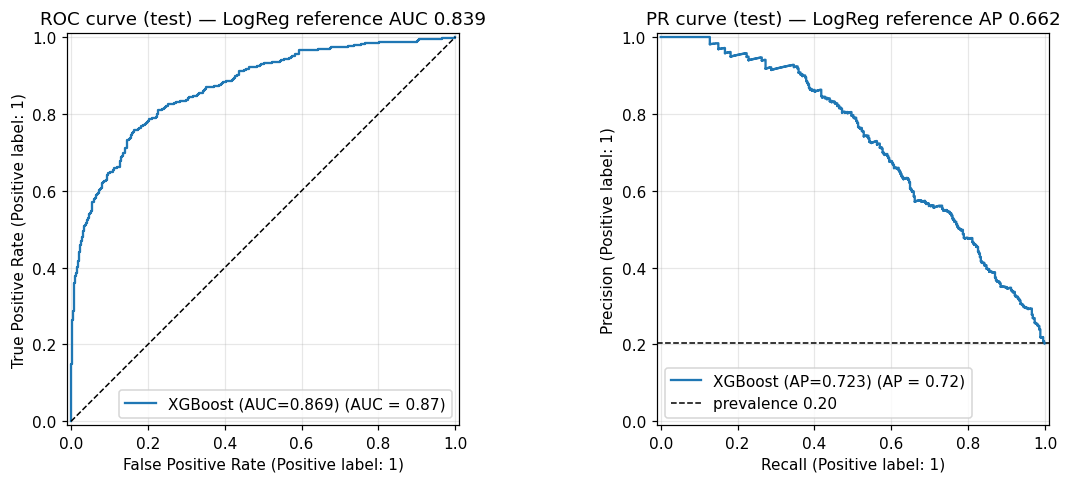

Test ROC-AUC: 0.8692  (LogReg: 0.8389, Δ = +0.0303)
Test PR-AUC : 0.7226  (LogReg: 0.6625, Δ = +0.0601)


In [6]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    average_precision_score, classification_report, confusion_matrix,
    f1_score, precision_recall_curve, roc_auc_score,
)

LOGREG_AUC, LOGREG_AP = 0.8389, 0.6625  # reference from 02_logistic_regression

p_test = final_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, p_test)
ap = average_precision_score(y_test, p_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
RocCurveDisplay.from_predictions(y_test, p_test, ax=axes[0],
                                 name=f"XGBoost (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title(f"ROC curve (test) — LogReg reference AUC {LOGREG_AUC:.3f}")

PrecisionRecallDisplay.from_predictions(y_test, p_test, ax=axes[1],
                                        name=f"XGBoost (AP={ap:.3f})")
axes[1].axhline(y_test.mean(), ls="--", c="k", lw=1,
                label=f"prevalence {y_test.mean():.2f}")
axes[1].legend()
axes[1].set_title(f"PR curve (test) — LogReg reference AP {LOGREG_AP:.3f}")
plt.tight_layout()
plt.show()

print(f"Test ROC-AUC: {auc:.4f}  (LogReg: {LOGREG_AUC:.4f}, Δ = {auc - LOGREG_AUC:+.4f})")
print(f"Test PR-AUC : {ap:.4f}  (LogReg: {LOGREG_AP:.4f}, Δ = {ap - LOGREG_AP:+.4f})")

### 6.2 Confusion matrices: default vs F1-optimal threshold

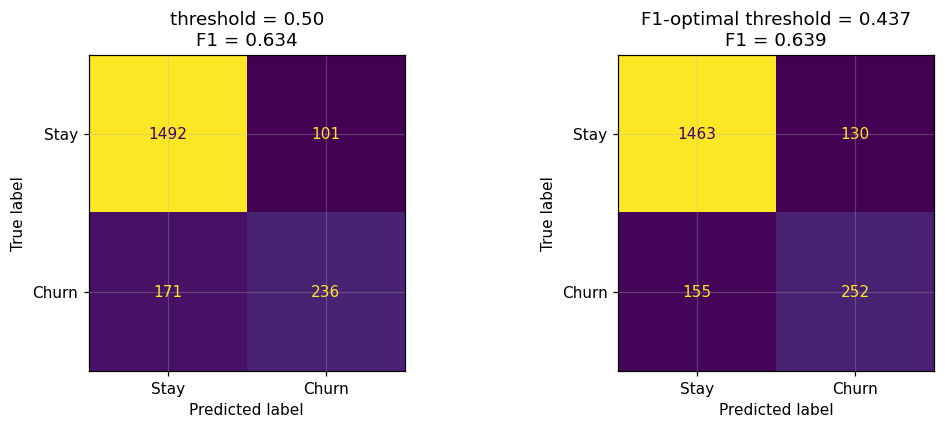

Classification report @ F1-optimal threshold:

              precision    recall  f1-score   support

        Stay       0.90      0.92      0.91      1593
       Churn       0.66      0.62      0.64       407

    accuracy                           0.86      2000
   macro avg       0.78      0.77      0.78      2000
weighted avg       0.85      0.86      0.86      2000



In [7]:
prec, rec, thr = precision_recall_curve(y_test, p_test)
f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
t_f1 = thr[f1_scores.argmax()]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, t, label in [(axes[0], 0.5, "threshold = 0.50"),
                     (axes[1], t_f1, f"F1-optimal threshold = {t_f1:.3f}")]:
    cm = confusion_matrix(y_test, p_test >= t)
    ConfusionMatrixDisplay(cm, display_labels=["Stay", "Churn"]).plot(
        ax=ax, colorbar=False, values_format="d")
    ax.set_title(f"{label}\nF1 = {f1_score(y_test, p_test >= t):.3f}")
plt.tight_layout()
plt.show()

print("Classification report @ F1-optimal threshold:\n")
print(classification_report(y_test, p_test >= t_f1, target_names=["Stay", "Churn"]))

### 6.3 Score distribution by class

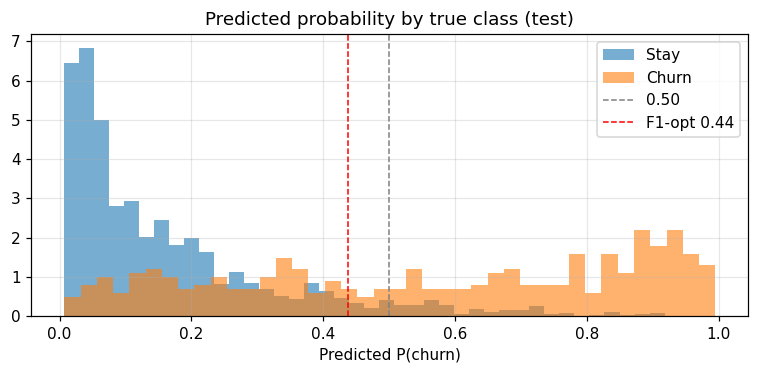

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for label, name in [(0, "Stay"), (1, "Churn")]:
    ax.hist(p_test[y_test == label], bins=40, alpha=0.6, density=True, label=name)
ax.axvline(0.5, ls="--", c="gray", lw=1, label="0.50")
ax.axvline(t_f1, ls="--", c="red", lw=1, label=f"F1-opt {t_f1:.2f}")
ax.set_xlabel("Predicted P(churn)")
ax.set_title("Predicted probability by true class (test)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Interpretability — SHAP (TreeExplainer)

For boosted trees SHAP is the native global+local explanation tool. Two checks against
EDA: the age effect should be non-linear, and the product-count dummies should show
2-products pulling risk *down* while 3/4-products push it sharply up.

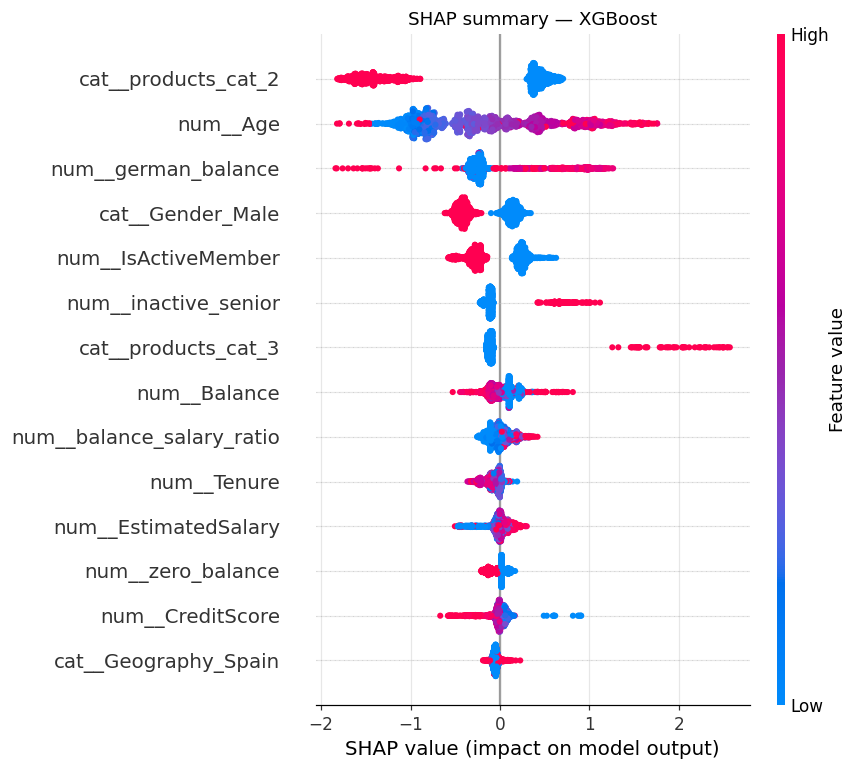

In [9]:
import shap

# A sliced imblearn pipeline containing the SMOTE step exposes no .transform
# (samplers only act at fit time), so apply the transformer steps explicitly.
_domain = final_model.named_steps["domain"]
_prep = final_model.named_steps["prep"]
feat_names = _prep.get_feature_names_out()
X_test_tr = pd.DataFrame(_prep.transform(_domain.transform(X_test)), columns=feat_names)

explainer = shap.TreeExplainer(final_model.named_steps["clf"])
shap_values = explainer.shap_values(X_test_tr)

shap.summary_plot(shap_values, X_test_tr, max_display=14, show=False)
plt.title("SHAP summary — XGBoost")
plt.tight_layout()
plt.show()

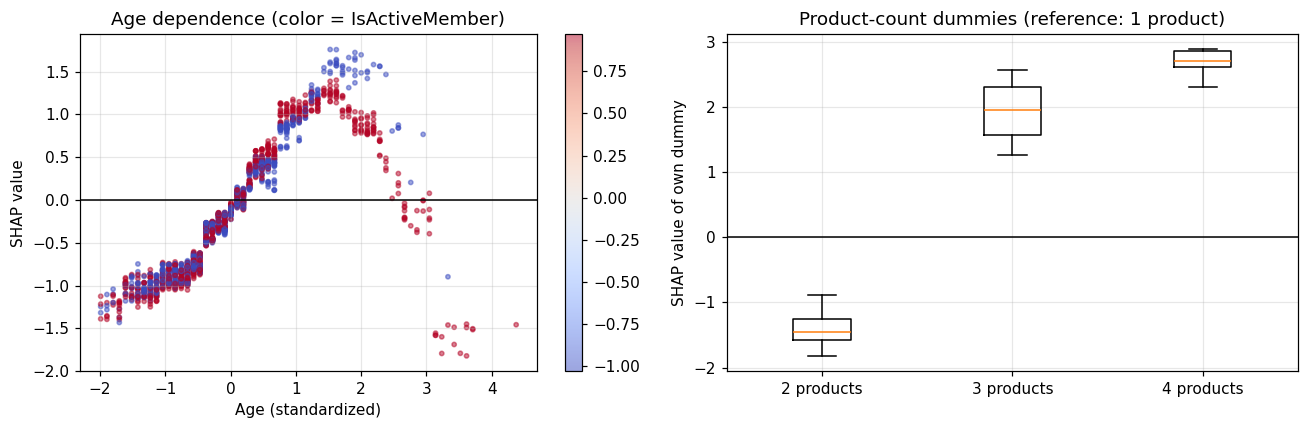

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
age_idx = list(feat_names).index("num__Age")
act_idx = list(feat_names).index("num__IsActiveMember")

sc = axes[0].scatter(X_test_tr["num__Age"], shap_values[:, age_idx],
                     c=X_test_tr["num__IsActiveMember"], cmap="coolwarm", s=8, alpha=0.5)
axes[0].axhline(0, c="k", lw=1)
axes[0].set_xlabel("Age (standardized)")
axes[0].set_ylabel("SHAP value")
axes[0].set_title("Age dependence (color = IsActiveMember)")
plt.colorbar(sc, ax=axes[0])

prod_cols = [c for c in feat_names if "products_cat" in c]
prod_shap = {c.split("_")[-1]: shap_values[X_test_tr[c] == 1][:, list(feat_names).index(c)]
             for c in prod_cols}
axes[1].boxplot(prod_shap.values(), tick_labels=[f"{k} products" for k in prod_shap])
axes[1].axhline(0, c="k", lw=1)
axes[1].set_ylabel("SHAP value of own dummy")
axes[1].set_title("Product-count dummies (reference: 1 product)")
plt.tight_layout()
plt.show()

## 8. Results summary & next step

| | Logistic (tuned) | XGBoost (tuned) |
|---|---|---|
| Test ROC-AUC | 0.8389 | printed in §6.1 |
| Test PR-AUC | 0.6625 | printed in §6.1 |
| Tuning protocol | Randomized (40) → Grid | identical |
| Imbalance handling | SMOTE in-pipeline | identical |

The gap over the linear baseline is exactly where EDA predicted it: the SHAP dependence
panels show a strongly non-linear age contribution and the U-shaped product effect —
structure a linear-in-features model cannot express regardless of tuning.

**Next:** `04_lightgbm.ipynb` — same protocol; then a series-closing comparison
(metrics + SHAP side-by-side + campaign-profit deltas across all three models).